In [ ]:
# use holodeck environment

In [ ]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [2]:
import holodeck as holo
import holodeck
from holodeck.constants import YR, NWTG, SPLC, GYR, PC, MSOL
from holodeck.galaxy_profiles import NFW
from holodeck import utils
from holodeck.librarian import DEF_NUM_FBINS, DEF_NUM_LOUDEST, DEF_PTA_DUR
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp, quad
import numpy as np
import kalepy as kale
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import os
import la_forge.core as co
from ceffyl.chain_utils import chain_utils
import la_forge.diagnostics as dg
from chainconsumer.chainconsumer import ChainConsumer
from emcee.autocorr import integrated_time

import numpy as np
import matplotlib.pyplot as plt

PINT not installed. PINT or libstempo are required to use par and tim files.


## for NNs

chain shape without mask (512000, 15)
max log posterior value is: -4.899559
Max Likelihood Array For Phenom: -1.51, 11.94, 7.86, 0.00, 0.50, -0.35
chain shape with mask (512000, 15)
<class 'holodeck.librarian.param_spaces_classic.PS_Classic_Phenom_Uniform'>
14:33:24 INFO : <holodeck.librarian.param_spaces_classic.PS_Classic_Phenom_Uniform object at 0x146ad458c130>: nsamples=None nparameters=6 - cannot generate parameter samples. [lib_tools.py:__init__]
14:33:24 INFO : Galaxy pair-fraction provided, using galaxy pair-fraction and merger-time. [sam.py:__init__]
14:33:27: starting calculating redz_final, diff_num
14:33:28 INFO : Adding MMbulge scatter (1.7545e-03) [sam.py:static_binary_density]
14:33:28 INFO : 	dens bef: (0.00e+00, 1.79e-160, 5.00e-28, 3.34e-04, 1.71e-02, 7.99e-02, 4.92e-01) [sam.py:static_binary_density]
14:33:57 INFO : Scatter added after 28.885768 sec [sam.py:static_binary_density]
14:33:57 INFO : 	dens aft: (0.00e+00, 1.55e-22, 3.78e-17, 3.35e-04, 1.71e-02, 7.99e-02, 

2026-03-13 14:36:52.022377: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 14:36:52.071388: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-13 14:36:52.071440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-13 14:36:52.073492: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-13 14:36:52.081301: I tensorflow/core/platform/cpu_feature_guar

strain_median = [6.26566329e-15 7.16299618e-15 7.13085843e-15 6.84197255e-15
 6.43626410e-15 6.05209842e-15 5.67485676e-15 5.29526622e-15
 4.96154102e-15 4.68082363e-15 4.43238785e-15 4.16333359e-15
 3.93239227e-15 3.71401010e-15 3.51372167e-15]
strain_lower = [5.96364643e-15 6.66103314e-15 6.51600890e-15 6.10578565e-15
 5.60290780e-15 5.18232395e-15 4.73494586e-15 4.36612358e-15
 3.97707079e-15 3.68958503e-15 3.44059201e-15 3.15320826e-15
 2.94385687e-15 2.75688644e-15 2.56430099e-15]
strain_upper = [6.76158364e-15 8.06987637e-15 8.49731081e-15 8.78070010e-15
 8.52199803e-15 8.28549519e-15 8.56113270e-15 8.26171810e-15
 7.73108826e-15 8.02738272e-15 7.55514654e-15 7.71130800e-15
 7.71296594e-15 7.05559923e-15 6.97505724e-15]


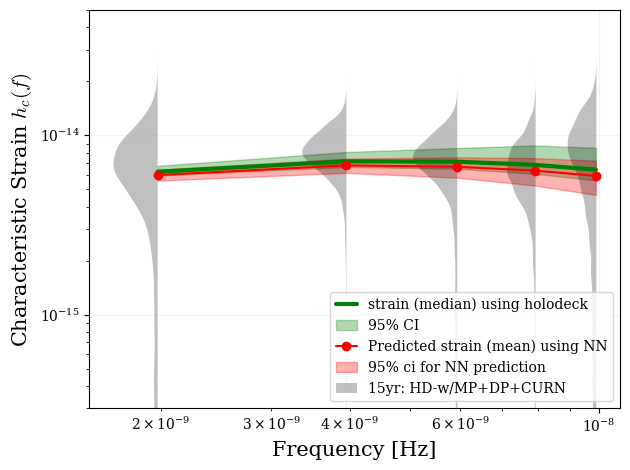

In [4]:
# mcmc using NN
chain_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/nn_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'

data = np.loadtxt(chain_path)
print('chain shape without mask', data.shape)
maxLidx = np.argmax(data[:, -4]) # 4th to last column is log posterior
print(f'max log posterior value is: {data[maxLidx, -4]}')
maxL = data[maxLidx, :6] # last 4 columns in mcmc chains here are log posterior, and other stuff

print("Max Likelihood Array For Phenom:", ", ".join("{:.2f}".format(ml) for ml in maxL))  # respects your .format preference

print('chain shape with mask', data.shape)

# strain calculation using the maxL params
# copied from /home/users/sti50/Codes/holodeck_latest_version_with_my_changes_strain_with_sidm.ipynb
nfreqs = 15
param_space = 'PS_Classic_Phenom_Uniform'
space_name = param_space.split(".")
space_class = holo.librarian.param_spaces_dict[space_name[0]] # /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 498)
print(space_class)
# for edges
pta_dur = holo.librarian.DEF_PTA_DUR # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 363)
fobs_cents, fobs_edges = utils.pta_freqs(dur=pta_dur*YR, num=nfreqs) # from line 787 from /home/users/sti50/.conda/envs/holodeck_ceffyl_ptmcmc/lib/python3.9/site-packages/holodeck/librarian/lib_tools.py
fobs_orb_cents = fobs_cents / 2.0
fobs_orb_edges = fobs_edges / 2.0
# if don't want to use resume
space = space_class() # inspired from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py line 516
# if don't want to use resume and use own params
maxL_param_values = maxL.tolist()
param_names = ['gsmf_phi0_log10', 'gsmf_mchar0_log10', 'mmb_mamp_log10', 'mmb_scatter_dex', 'hard_time', 'hard_gamma_inner']
params_maxL = dict(zip(param_names, maxL_param_values))
params = params_maxL
sam, hard = space.model_for_params(params) # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 302)

# strain using holodeck
gwb_for_maxL_params = holo.librarian.lib_tools.run_model(
    sam, hard,
    pta_dur=DEF_PTA_DUR, nfreqs=nfreqs, nreals=2000, nloudest=DEF_NUM_LOUDEST,
    gwb_flag=True, singles_flag=False, details_flag=False, params_flag=False,
    log=None,
)

NFREQS = 5
etac = maxL

nn_dir = Path(chain_path).parents[2] / 'nn_training_output'

from tensorflow import keras
import os
import tensorflow_probability as tfp
tfpl = tfp.layers
tfd = tfp.distributions
model_median = keras.models.load_model(os.path.join(nn_dir, "nn_model_median.keras"),
      custom_objects={"DistributionLambda": tfpl.DistributionLambda},
      compile=False,safe_mode=False)

model_std = keras.models.load_model(os.path.join(nn_dir, "nn_model_std.keras"),
      custom_objects={"DistributionLambda": tfpl.DistributionLambda},
      compile=False,safe_mode=False)

normalization_params = np.load(os.path.join(nn_dir, "normalization_params.npz"))
mu_x = normalization_params["mu_x"]
std_x = normalization_params["std_x"]
mu_y_median = normalization_params["mu_y_median"]
std_y_median = normalization_params["std_y_median"]
std_y_std = normalization_params["std_y_std"]

unnormalized_test_param = etac.reshape(1, len(etac)) # shape (1, 6)
normalized_test_param = (unnormalized_test_param - mu_x) / std_x
y_pred_dist_median = model_median(normalized_test_param)
y_pred_median_nn = y_pred_dist_median.mean()
y_pred_median_unc_nn = y_pred_dist_median.stddev()
y_pred_dist_std = model_std(normalized_test_param)
y_pred_std_nn = y_pred_dist_std.mean()
y_pred_std_unc_nn = y_pred_dist_std.stddev()
y_pred_total_std_nn = np.sqrt(y_pred_median_unc_nn**2 + y_pred_std_nn**2 + y_pred_std_unc_nn**2)
y_pred_total_original_std_nn = y_pred_total_std_nn * std_y_std
y_pred_original_median_nn = y_pred_median_nn * std_y_median + mu_y_median
max_spec_sidm = 10**(y_pred_original_median_nn.numpy().reshape(5,) / 2)
rho_pred = y_pred_total_original_std_nn.reshape(5,)

max_spec_sidm_std = 0.5 * np.log(10) * max_spec_sidm * rho_pred # using chatGPT

import numpy as np
import matplotlib.pyplot as plt
import kalepy as kale
import la_forge.core as co

# Assume gwb_maxL_params['gwb'].shape == (40, 1000)
strain_realizations = gwb_for_maxL_params['gwb']  # shape: (n_freqs, n_samples)
frequencies = fobs_cents  # shape: (n_freqs,)

# Compute statistics
strain_median = np.median(strain_realizations, axis=1)
strain_lower = np.percentile(strain_realizations, 2.5, axis=1)
strain_upper = np.percentile(strain_realizations, 97.5, axis=1)
print(f'strain_median = {strain_median}')
print(f'strain_lower = {strain_lower}')
print(f'strain_upper = {strain_upper}')
# Plotting
# plt.figure(figsize=(8, 6))
# plt.figure(figsize=(8, 6))
plt.loglog(frequencies[0:NFREQS], strain_median[0:NFREQS], color='green', lw=3, label='strain (median) using holodeck')
plt.fill_between(frequencies[0:NFREQS], strain_lower[0:NFREQS], strain_upper[0:NFREQS], color='green', alpha=0.3, label='95% CI')

# strain using NNs
plt.loglog(fobs_cents[0:NFREQS], max_spec_sidm, color='red', marker='o', label='Predicted strain (mean) using NN')
plt.fill_between(fobs_cents[0:NFREQS], max_spec_sidm - 2*max_spec_sidm_std, max_spec_sidm + 2*max_spec_sidm_std, color='red', alpha=0.3, label='95% ci for NN prediction')

#### for left violin
from holodeck import plot, utils
# Load 15-year data
# insert your own path here
my_path = f'{PROJECT_ROOT}/Data/holodeck_astro_data_luke_kelly/' # added by me
chain_hdall = co.Core(corepath= my_path + 'freespec_posteriors/freespec_hd_all.core')
freqs = fobs_cents
Tspan = DEF_PTA_DUR * YR
# for ii in range(14):
for ii in range(5):
   if ii < 6:
      idx = np.where(chain_hdall(chain_hdall.params[(-64+ii)]) > -9)
      dd = chain_hdall(chain_hdall.params[(-64+ii)])[idx]
   else:
      dd = chain_hdall(chain_hdall.params[(-64+ii)])
   yy, zz = kale.density(dd, probability=True)
   hc = (np.sqrt((10**yy)**2 * (12*np.pi**2*freqs[ii]**3*Tspan)))
   if ii == 0:
      plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.15, 
                  side='left', color='k', median=False, line=None, label=r'15yr: HD-w/MP+DP+CURN')
   elif 0 < ii < 3:
      plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.15, 
                  side='left', color='k', median=False, line=None)
   elif 2 < ii < 5:
      plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.1, 
                  side='left', color='k', median=False, line=None)
   # elif 4 < ii < 8:
   #    plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.075, 
   #                side='left', color='k', median=False, line=None)
   # else:
   #    plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.05, 
   #                side='left', color='k', median=False, line=None)


# Customize ticks, labels, limits
plt.xlabel("Frequency [Hz]", fontsize=15)
plt.ylabel(r"Characteristic Strain $h_c(f)$", fontsize=15)
# plt.xlim(1.5e-9, 3e-8)
plt.ylim(3e-16, 5e-14)
plt.legend(loc='lower right')
# plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



## for GPs

chain shape without mask (274100, 15)
max log posterior value is: -4.242628
Max Likelihood Array For Phenom: -1.53, 11.14, 8.71, 0.06, 0.49, -0.52
chain shape with mask (274100, 15)
<class 'holodeck.librarian.param_spaces_classic.PS_Classic_Phenom_Uniform'>
14:29:24 INFO : <holodeck.librarian.param_spaces_classic.PS_Classic_Phenom_Uniform object at 0x146b5df93850>: nsamples=None nparameters=6 - cannot generate parameter samples. [lib_tools.py:__init__]
14:29:24 INFO : Galaxy pair-fraction provided, using galaxy pair-fraction and merger-time. [sam.py:__init__]
14:29:28: starting calculating redz_final, diff_num
14:29:28 INFO : Adding MMbulge scatter (6.0203e-02) [sam.py:static_binary_density]
14:29:28 INFO : 	dens bef: (0.00e+00, 1.07e-171, 9.93e-30, 2.98e-04, 1.59e-02, 7.45e-02, 4.60e-01) [sam.py:static_binary_density]
14:29:57 INFO : Scatter added after 29.024536 sec [sam.py:static_binary_density]
14:29:57 INFO : 	dens aft: (4.78e-107, 3.53e-22, 2.48e-16, 3.18e-04, 1.62e-02, 7.58e-02,

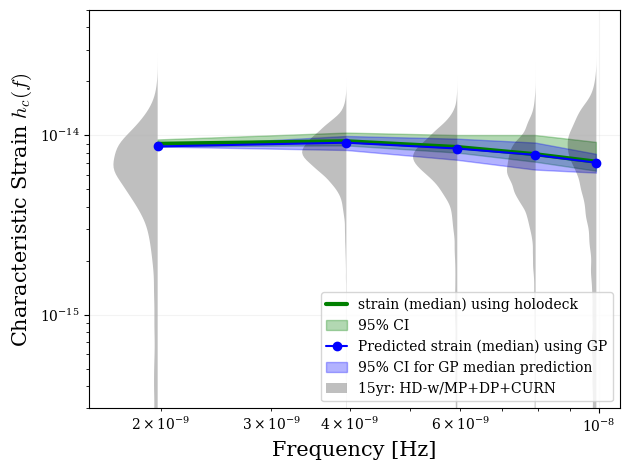

In [ ]:
# mcmc using GP
chain_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n2000_r2000_f5/gp_mcmc_log_likelihood_all_freqs/ceffyl_output_hd_mp_dp_curn/chain_1.txt'

data = np.loadtxt(chain_path)
print('chain shape without mask', data.shape)
maxLidx = np.argmax(data[:, -4]) # 4th to last column is log posterior
print(f'max log posterior value is: {data[maxLidx, -4]}')
maxL = data[maxLidx, :6] # last 4 columns in mcmc chains here are log posterior, and other stuff

print("Max Likelihood Array For Phenom:", ", ".join("{:.2f}".format(ml) for ml in maxL))  # respects your .format preference

print('chain shape with mask', data.shape)

# strain calculation using the maxL params
# copied from /home/users/sti50/Codes/holodeck_latest_version_with_my_changes_strain_with_sidm.ipynb
nfreqs = 15
param_space = 'PS_Classic_Phenom_Uniform'
space_name = param_space.split(".")
space_class = holo.librarian.param_spaces_dict[space_name[0]] # /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 498)
print(space_class)
# for edges
pta_dur = holo.librarian.DEF_PTA_DUR # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 363)
fobs_cents, fobs_edges = utils.pta_freqs(dur=pta_dur*YR, num=nfreqs) # from line 787 from /home/users/sti50/.conda/envs/holodeck_ceffyl_ptmcmc/lib/python3.9/site-packages/holodeck/librarian/lib_tools.py
fobs_orb_cents = fobs_cents / 2.0
fobs_orb_edges = fobs_edges / 2.0
# if don't want to use resume
space = space_class() # inspired from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py line 516
# if don't want to use resume and use own params
maxL_param_values = maxL.tolist()
param_names = ['gsmf_phi0_log10', 'gsmf_mchar0_log10', 'mmb_mamp_log10', 'mmb_scatter_dex', 'hard_time', 'hard_gamma_inner']
params_maxL = dict(zip(param_names, maxL_param_values))
params = params_maxL
sam, hard = space.model_for_params(params) # from /home/users/sti50/holodeck/holodeck/librarian/gen_lib.py (line 302)

# strain using holodeck
gwb_for_maxL_params = holo.librarian.lib_tools.run_model(
    sam, hard,
    pta_dur=DEF_PTA_DUR, nfreqs=nfreqs, nreals=2000, nloudest=DEF_NUM_LOUDEST,
    gwb_flag=True, singles_flag=False, details_flag=False, params_flag=False,
    log=None,
)

NFREQS = 5

####### for GP trained on the same training set
test_array = maxL
from holodeck.gps import gp_utils
import pickle, h5py, glob, os
from pathlib import Path
NFREQS = 5
# GPs with 2000 points (parellelized)
GW_var_gp_george_pkl = [Path(chain_path).parents[2] / 'gp_training_output/std.pkl']
GW_gp_george_pkl = [Path(chain_path).parents[2] / 'gp_training_output/med.pkl']
# open gp_george objects
GW_gp_george = pickle.load(open(GW_gp_george_pkl[0], 'rb'))
GW_var_gp_george = pickle.load(open(GW_var_gp_george_pkl[0], 'rb'))
# make gaussprob objects
spectra = None
GW_gp = gp_utils.set_up_predictions(spectra, GW_gp_george)
GW_var_gp = gp_utils.set_up_predictions(spectra, GW_var_gp_george)
max_spec_sidm_gp, rho_gp, rho_pred_gp = gp_utils.hc_from_gp(GW_gp_george[:NFREQS], GW_gp[:NFREQS],
                                                   GW_var_gp_george[:NFREQS], GW_var_gp[:NFREQS],
                                                   #    maxL)
                                                   test_array)

max_spec_sidm_std_gp = 0.5 * np.log(10) * max_spec_sidm_gp * rho_pred_gp[:, 1] # using chatGPT

import numpy as np
import matplotlib.pyplot as plt
import kalepy as kale
import la_forge.core as co

# Assume gwb_maxL_params['gwb'].shape == (40, 1000)
strain_realizations = gwb_for_maxL_params['gwb']  # shape: (n_freqs, n_samples)
frequencies = fobs_cents  # shape: (n_freqs,)

# Compute statistics
strain_median = np.median(strain_realizations, axis=1)
strain_lower = np.percentile(strain_realizations, 2.5, axis=1)
strain_upper = np.percentile(strain_realizations, 97.5, axis=1)
print(f'strain_median = {strain_median}')
print(f'strain_lower = {strain_lower}')
print(f'strain_upper = {strain_upper}')
# Plotting
# plt.figure(figsize=(8, 6))
# plt.figure(figsize=(8, 6))
plt.loglog(frequencies[0:NFREQS], strain_median[0:NFREQS], color='green', lw=3, label='strain (median) using holodeck')
plt.fill_between(frequencies[0:NFREQS], strain_lower[0:NFREQS], strain_upper[0:NFREQS], color='green', alpha=0.3, label='95% CI')

# strain using GPs
plt.loglog(fobs_cents[0:NFREQS], max_spec_sidm_gp, color='blue', marker='o', label='Predicted strain (median) using GP')
plt.fill_between(fobs_cents[0:NFREQS], max_spec_sidm_gp - 2*max_spec_sidm_std_gp, max_spec_sidm_gp + 2*max_spec_sidm_std_gp, color='blue', alpha=0.3, label='95% CI for GP median prediction')

#### for left violin
from holodeck import plot, utils
# Load 15-year data
# insert your own path here
my_path = f'{PROJECT_ROOT}/Data/holodeck_astro_data_luke_kelly/' # added by me
chain_hdall = co.Core(corepath= my_path + 'freespec_posteriors/freespec_hd_all.core')
freqs = fobs_cents
Tspan = DEF_PTA_DUR * YR
# for ii in range(14):
for ii in range(5):
   if ii < 6:
      idx = np.where(chain_hdall(chain_hdall.params[(-64+ii)]) > -9)
      dd = chain_hdall(chain_hdall.params[(-64+ii)])[idx]
   else:
      dd = chain_hdall(chain_hdall.params[(-64+ii)])
   yy, zz = kale.density(dd, probability=True)
   hc = (np.sqrt((10**yy)**2 * (12*np.pi**2*freqs[ii]**3*Tspan)))
   if ii == 0:
      plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.15, 
                  side='left', color='k', median=False, line=None, label=r'15yr: HD-w/MP+DP+CURN')
   elif 0 < ii < 3:
      plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.15, 
                  side='left', color='k', median=False, line=None)
   elif 2 < ii < 5:
      plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.1, 
                  side='left', color='k', median=False, line=None)
   # elif 4 < ii < 8:
   #    plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.075, 
   #                side='left', color='k', median=False, line=None)
   # else:
   #    plot.violin(plt.gca(), (freqs[ii]), hc, zz, width=freqs[ii]*0.05, 
   #                side='left', color='k', median=False, line=None)


# Customize ticks, labels, limits
plt.xlabel("Frequency [Hz]", fontsize=15)
plt.ylabel(r"Characteristic Strain $h_c(f)$", fontsize=15)
# plt.xlim(1.5e-9, 3e-8)
plt.ylim(3e-16, 5e-14)
plt.legend(loc='lower right')
# plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

